## RNN
- sequential data : 데이터 값 뿐 아니라 순서도 중요한 데이터
- ex) word, sentence, time series, ...
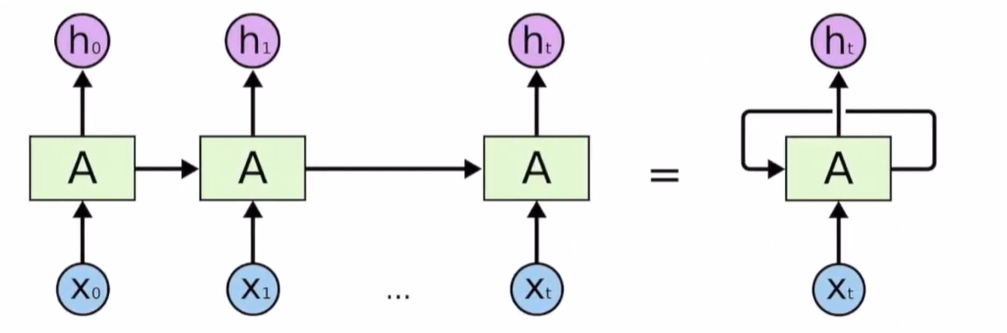
- A : hidden state -> 바깥에서는 보이지 않지만 그 전 입력값들 처리 결과를 반영함. 데이터 순서를 이야기하게 됨. 
- RNN에서는 hidden state를 통해 이전의 어떤 문자가 나왔다는 사실을 전달하기 때문에 모델이 순서를 이해한 것 처럼 정확하게 알게 됨.
- 긴 시퀀스가 들어와도 A에 들어가는 파라미터만 알고 있으면 언제든지 다음 단어 예측하는 모델을 정상적으로 작동시킬 수 있음.
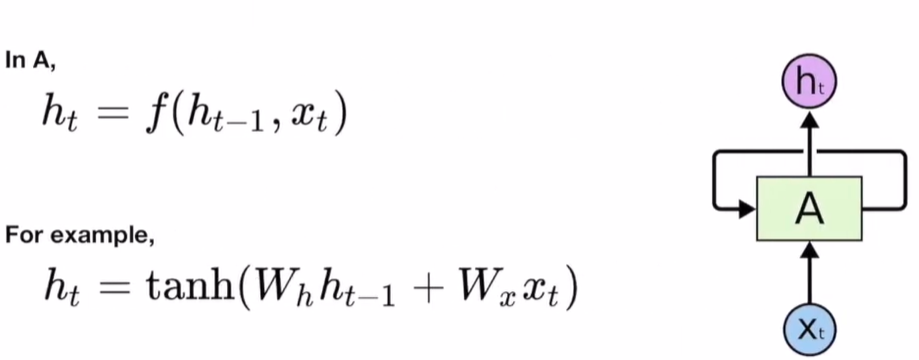

### LSTM & GRU (RNN의 발전형)
- 기본 RNN의 기억력 문제를 해결하기 위해 gate라는 장치를 추가한 모델
- LSTM : 정보를 '삭제, 저장, 출력'하는 3개의 문을 두어 중요한 정보를 아주 오래 기억함.
- GRU : LSTM의 구조를 단순화해 계산 속도를 높인 모델 (LSTM와 성능은 비슷)
- 복잡도 : 기본 < GRU < LSTM

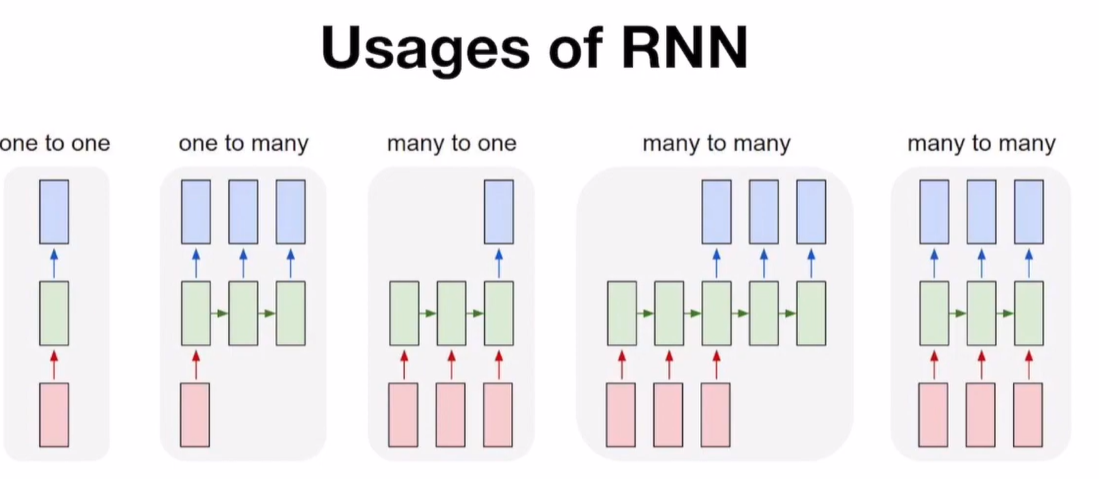
- one to one : 일반적인 뉴럴 네트워크 (RNN x)
- one to many : 하나의 이미지에 대해 여러 문장 출력
- many to one : 문장이 입력되면 감정에 대한 레이블 출력
- many to many : 
1. 문장을 끝까지 보고 출력하는 경우 -> 문장 들어오고 문장 출력 (번역 task)
2. 비디오를 받아 출력값 나옴 (끝까지 안보고 x)

#### output size = hidden size
A에서 출력 직전에 똑같은 값이 두개로 갈라짐 -> output, hidden
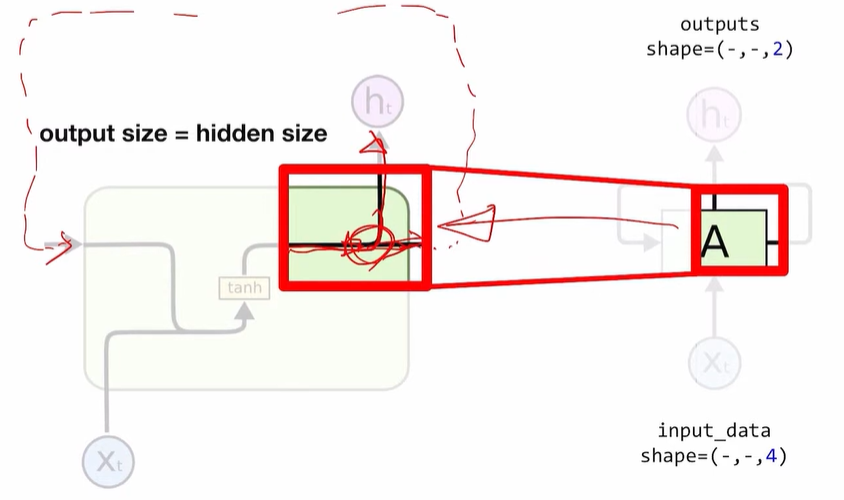

#### sequence length
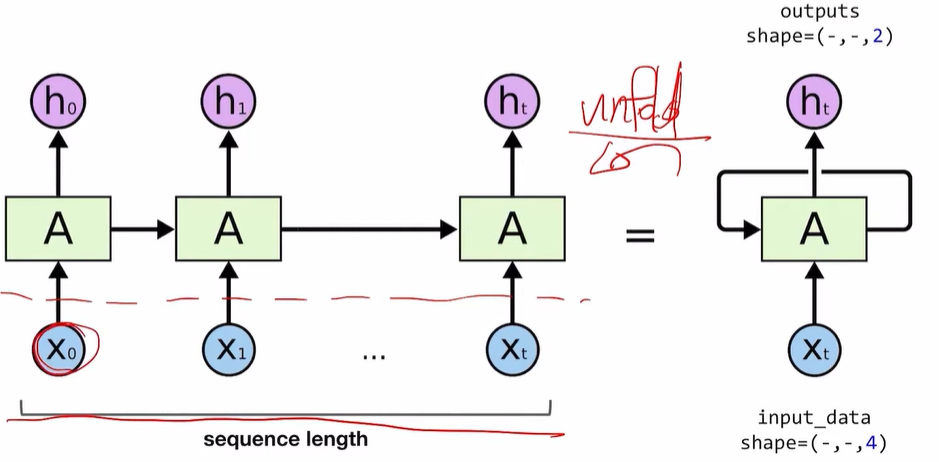
이 사진에서는 t + 1이 sequence length
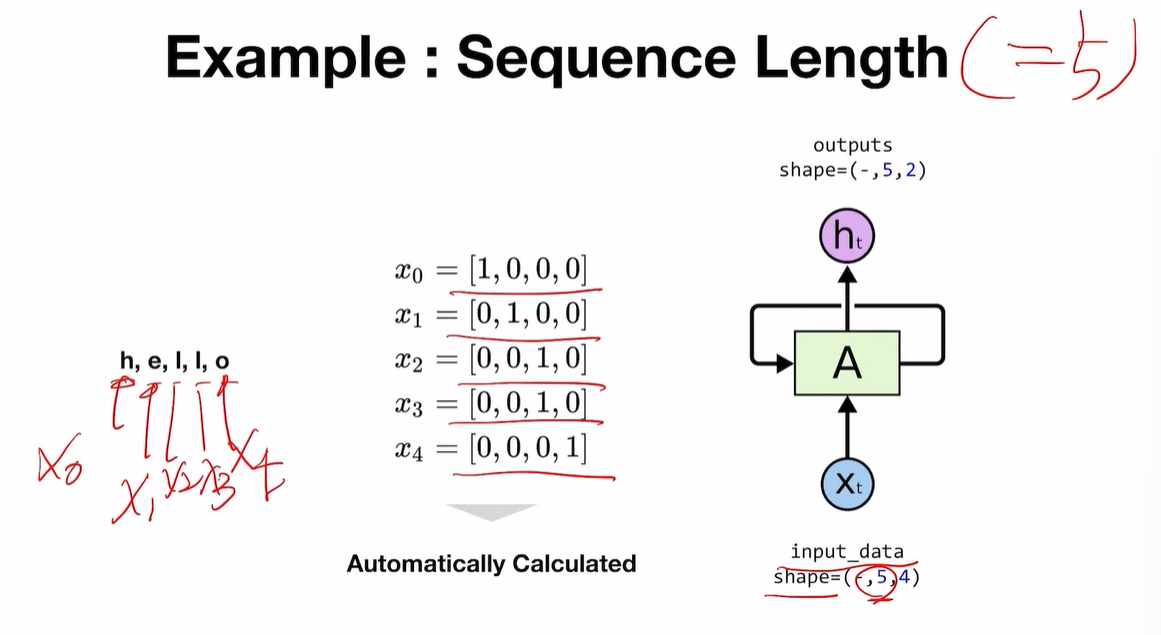

#### batch size
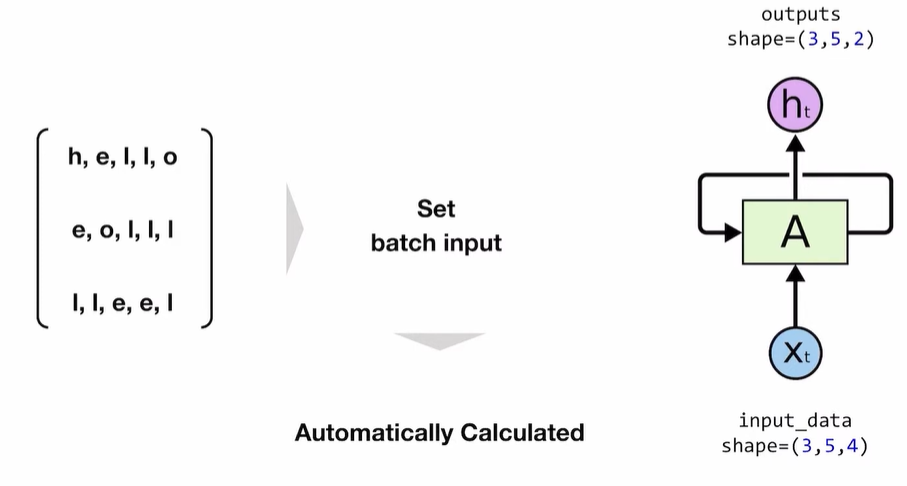
해당 사진에서는 3이 batch size

- 파이토치에서는 이런 개념들을 명시하지 않아도 알아서 모델이 알아냄.

#### hello, eolll, lleel 를 하나의 배치로 만들어서 인풋 데이터로 만들고 해당 데이터를 RNN에 넣음. 
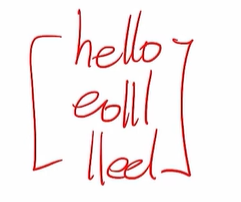

In [1]:
import torch
import numpy as np

input_size = 4
hidden_size = 2

##### input data tensor를 만드는 과정

In [2]:
h = [1, 0, 0, 0]
e = [0, 1, 0, 0]
l = [0, 0, 1, 0]
o = [0, 0, 0, 1]

input_data_np = np.array([[h, e, l, l, o],
                          [e, o, l, l, l],
                          [l, l, e, e, l]], dtype = np.float32)

# transform as torch tensor
input_data = torch.Tensor(input_data_np)

##### RNN 구동하는 코드

In [3]:
rnn = torch.nn.RNN(input_size, hidden_size)
outputs, _status = rnn(input_data)

output check

In [ ]:
print(outputs) 
print(outputs.size())# (3, 5, 2) -> batch size : 3, sequence length : 5, output_size : 2

tensor([[[-0.4255, -0.6396],
         [-0.6496, -0.3811],
         [ 0.4101, -0.5985],
         [ 0.4101, -0.5985],
         [-0.6205, -0.9061]],

        [[-0.6288, -0.5983],
         [-0.4590, -0.9513],
         [ 0.0427, -0.5513],
         [ 0.0427, -0.5513],
         [ 0.4582, -0.8033]],

        [[ 0.5301, -0.7851],
         [ 0.3770, -0.7808],
         [-0.7443, -0.4445],
         [-0.7443, -0.4445],
         [-0.0431, -0.5616]]], grad_fn=<StackBackward0>)
torch.Size([3, 5, 2])
